# Titanic

 ## Quick overview

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

BASE_DIR = Path("titanic")
csv_path = BASE_DIR / "train.csv"
train_data = pd.read_csv(csv_path)
csv_path = BASE_DIR / "test.csv"
test_data = pd.read_csv(csv_path)

train_data.head(20)


In [ ]:
train_data.tail(20)

In [15]:
train_data.shape

(891, 12)

In [ ]:
train_data.info()

In [ ]:
train_data.describe()

In [ ]:
train_data.describe(include=["object", "string"])

In [22]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

можно заметить что у многих не указан возраст и кабина

In [18]:
train_data.duplicated().sum()

np.int64(0)

In [27]:
cat_like_cols = ["Sex", "Embarked", "Pclass"]

for col in cat_like_cols:
    print(f"\n=== {col} ===")
    print("nunique (dropna=False):", train_data[col].nunique(dropna=False))
    print(train_data[col].value_counts(dropna=False).head(10))


=== Sex ===
nunique (dropna=False): 2
Sex
male      577
female    314
Name: count, dtype: int64

=== Embarked ===
nunique (dropna=False): 4
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

=== Pclass ===
nunique (dropna=False): 3
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


## Missing values & cleaning

In [ ]:
df = train_data.copy()

missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100 ).round(2),
    "dtype": df.dtypes.astype(str)
}).sort_values("missing_count", ascending=False)

display(missing)

,missing_count,missing_pct,dtype
Cabin,687,77.10,str
Age,177,19.87,float64
Embarked,2,0.22,str
PassengerId,0,0.00,int64
Name,0,0.00,str
Pclass,0,0.00,int64
Survived,0,0.00,int64
Sex,0,0.00,str
Parch,0,0.00,int64
SibSp,0,0.00,int64


Нам нужно заполнить Cabin, Age остальное не критично

In [26]:
df_drop_rows = df.dropna()
df_drop_collumns = df.dropna(axis=1)

print("Before drop:", df.shape)
print("After drop rows:", df_drop_rows.shape)
print("After drop collumns:", df_drop_collumns.shape)

Before drop: (891, 12)
After drop rows: (183, 12)
After drop collumns: (891, 9)


Можно заметить, что после удаления мы теряем больше половины данных

In [ ]:
df_clean = df.copy()

col = "Embarked"
mode_val = df_clean[col].mode(dropna=True)
mode_val = mode_val.iloc[0] if len(mode_val) else "Unknown"

df_clean[col] = df_clean[col].fillna(mode_val)
print("Embarked mode used:", mode_val)

mode = S


Заполним это модой потому что пропусков мало

In [32]:
col = "Age"
median_age = df_clean[col].median()
df_clean[col] = df_clean[col].fillna(median_age)

print("Age median used:", median_age)

Age median used: 28.0


Заполним медианой потому что пропусков не сильно много, поэтому можно примерно прикинуть медианное значение, мода не подходит потому что пропусков достаточно и она может быть неверной


In [33]:
if "Cabin" in df_clean.columns:
    df_clean["CabinKnown"] = df_clean["Cabin"].notna().astype(int)
    df_clean["Deck"] = df_clean["Cabin"].astype(str).str[0]
    df_clean.loc[df_clean["Cabin"].isna(), "Deck"] = "Unknown"
    df_clean["Cabin"] = df_clean["Cabin"].fillna("Unknown")

In [34]:
dup = df_clean.duplicated().sum()
print(dup)

0


У нас нет дупликатов

In [35]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
 12  CabinKnown   891 non-null    int64  
 13  Deck         891 non-null    str    
dtypes: float64(2), int64(6), str(6)
memory usage: 97.6 KB


Ничего не сломалось)

In [36]:
missing_after = df_clean.isna().sum().sort_values(ascending=False)
display(missing_after[missing_after > 0])

print("Total missing cells:", df_clean.isna().sum().sum())

Series([], dtype: int64)

Total missing cells: 0


## Advanced statistics

In [45]:
num_cols = df_clean.select_dtypes(include='number').columns

exclude = {"Survived", "PassengerId"}
num_feature_cols = [c for c in num_cols if c not in exclude]

num_feature_cols

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'CabinKnown']

In [46]:
basic = pd.DataFrame(index=num_feature_cols)

basic["count"] = df_clean[num_feature_cols].count()
basic["min"] = df_clean[num_feature_cols].min()
basic["max"] = df_clean[num_feature_cols].max()
basic["mean"] = df_clean[num_feature_cols].mean()
basic["median"] = df_clean[num_feature_cols].median()

basic["mode"] = [
    df_clean[c].mode(dropna=True).iloc[0] if len(df_clean[c].mode(dropna=True)) else np.nan for c in num_feature_cols
]

display(basic)

,count,min,max,mean,median,mode
Pclass,891,1.00,3.0000,2.308642,3.0000,3.00
Age,891,0.42,80.0000,29.361582,28.0000,28.00
SibSp,891,0.00,8.0000,0.523008,0.0000,0.00
Parch,891,0.00,6.0000,0.381594,0.0000,0.00
Fare,891,0.00,512.3292,32.204208,14.4542,8.05
CabinKnown,891,0.00,1.0000,0.228956,0.0000,0.00


In [47]:
q = df_clean[num_feature_cols].quantile([0.05, 0.25, 0.50, 0.75, 0.95]).T
q.columns = ["q05", "q25", "q50", "q75", "q95"]

display(q)

,q05,q25,q50,q75,q95
Pclass,1.000,2.0000,3.0000,3.0,3.00000
Age,6.000,22.0000,28.0000,35.0,54.00000
SibSp,0.000,0.0000,0.0000,1.0,3.00000
Parch,0.000,0.0000,0.0000,0.0,2.00000
Fare,7.225,7.9104,14.4542,31.0,112.07915
CabinKnown,0.000,0.0000,0.0000,0.0,1.00000


In [48]:
extra = pd.DataFrame(index=num_feature_cols)

extra["variance"] = df_clean[num_feature_cols].var()
extra["skewness"] = df_clean[num_feature_cols].skew()
extra["kurtosis"] = df_clean[num_feature_cols].kurt()

display(extra)

,variance,skewness,kurtosis
Pclass,0.699015,-0.630548,-1.280015
Age,169.512498,0.510245,0.993871
SibSp,1.216043,3.695352,17.880420
Parch,0.649728,2.749117,9.778125
Fare,2469.436846,4.787317,33.398141
CabinKnown,0.176734,1.292367,-0.330535


In [49]:
advanced_stats = pd.concat([basic, q, extra], axis=1)
display(advanced_stats)

,count,min,max,mean,median,mode,q05,q25,q50,q75,q95,variance,skewness,kurtosis
Pclass,891,1.00,3.0000,2.308642,3.0000,3.00,1.000,2.0000,3.0000,3.0,3.00000,0.699015,-0.630548,-1.280015
Age,891,0.42,80.0000,29.361582,28.0000,28.00,6.000,22.0000,28.0000,35.0,54.00000,169.512498,0.510245,0.993871
SibSp,891,0.00,8.0000,0.523008,0.0000,0.00,0.000,0.0000,0.0000,1.0,3.00000,1.216043,3.695352,17.880420
Parch,891,0.00,6.0000,0.381594,0.0000,0.00,0.000,0.0000,0.0000,0.0,2.00000,0.649728,2.749117,9.778125
Fare,891,0.00,512.3292,32.204208,14.4542,8.05,7.225,7.9104,14.4542,31.0,112.07915,2469.436846,4.787317,33.398141
CabinKnown,891,0.00,1.0000,0.228956,0.0000,0.00,0.000,0.0000,0.0000,0.0,1.00000,0.176734,1.292367,-0.330535


## Encoding & Feature Engineering 

In [53]:
df_fe = df_clean.copy()

df_fe["FamilySize"] = df_fe["SibSp"] + df_fe["Parch"] + 1
df_fe["IsAlone"] = df_fe["FamilySize"] == 1
df_fe["Title"] = df_fe["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)
df_fe["Title"] = df_fe["Title"].fillna("Unknown")

top_titles = df_fe["Title"].value_counts().head(5).index
df_fe["Title"] =np.where(df_fe["Title"].isin(top_titles), df_fe["Title"], "Other")

df_fe["TicketStr"] = df_fe["Ticket"].astype(str)
df_fe["TicketPrefix"] = df_fe["TicketStr"].str.replace(r"\d+", "", regex=True).str.strip()
df_fe["TicketPrefix"] = df_fe["TicketPrefix"].replace("", "NONE")

cols_show = ["SibSp","Parch","FamilySize","IsAlone","Title","Ticket","TicketPrefix"]
display(df_fe[cols_show].head(10))

,SibSp,Parch,FamilySize,IsAlone,Title,Ticket,TicketPrefix
0,1,0,2,False,Mr,A/5 21171,A/
1,1,0,2,False,Mrs,PC 17599,PC
2,0,0,1,True,Miss,STON/O2. 3101282,STON/O.
3,1,0,2,False,Mrs,113803,NONE
4,0,0,1,True,Mr,373450,NONE
5,0,0,1,True,Mr,330877,NONE
6,0,0,1,True,Mr,17463,NONE
7,3,1,5,False,Master,349909,NONE
8,0,2,3,False,Mrs,347742,NONE
9,1,0,2,False,Mrs,237736,NONE


Создадим копию, с которой можно эксперементировать

In [56]:
target_col = "Survived"
X = df_fe.drop(columns=target_col)
Y = df_fe[target_col]

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

num_cols, cat_cols

(['PassengerId',
  'Pclass',
  'Age',
  'SibSp',
  'Parch',
  'Fare',
  'CabinKnown',
  'FamilySize'],
 ['Name',
  'Sex',
  'Ticket',
  'Cabin',
  'Embarked',
  'Deck',
  'Title',
  'TicketStr',
  'TicketPrefix'])

In [55]:
X_ohe = pd.get_dummies(X, columns=cat_cols, drop_first=False)
print("Before:", X.shape, "After OHE:", X_ohe.shape)
display(X_ohe.head())

Before: (891, 18) After OHE: (891, 2473)


,PassengerId,Pclass,Age,SibSp,Parch,Fare,CabinKnown,FamilySize,IsAlone,"Name_Abbing, Mr. Anthony",...,TicketPrefix_SOTON/O,TicketPrefix_SOTON/O.Q.,TicketPrefix_SOTON/OQ,TicketPrefix_STON/O .,TicketPrefix_STON/O.,TicketPrefix_SW/PP,TicketPrefix_W./C.,TicketPrefix_W.E.P.,TicketPrefix_W/C,TicketPrefix_WE/P
0,1,3,22.0,1,0,7.2500,0,2,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,1,38.0,1,0,71.2833,1,2,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,3,26.0,0,0,7.9250,0,1,True,False,...,False,False,False,False,True,False,False,False,False,False
3,4,1,35.0,1,0,53.1000,1,2,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3,35.0,0,0,8.0500,0,1,True,False,...,False,False,False,False,False,False,False,False,False,False



## Visualizations

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

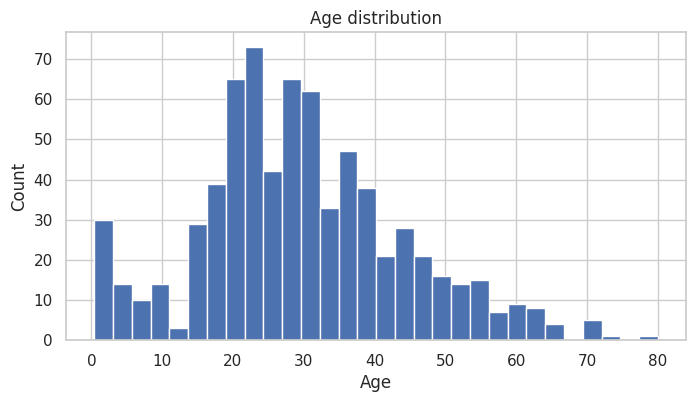

In [58]:
plt.hist(df["Age"], bins=30)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

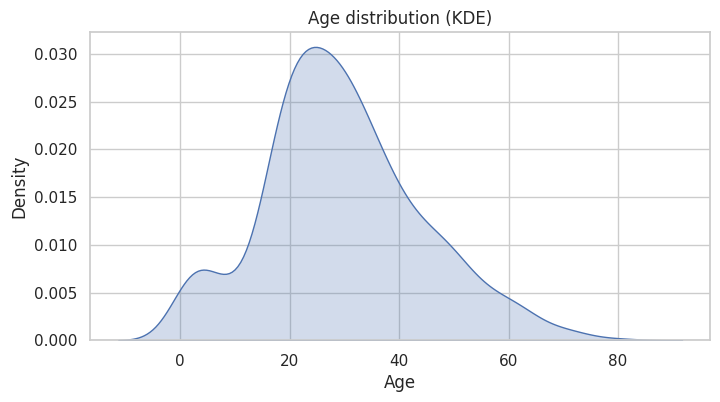

In [59]:
sns.kdeplot(data=df, x="Age", fill=True)
plt.title("Age distribution (KDE)")
plt.show()

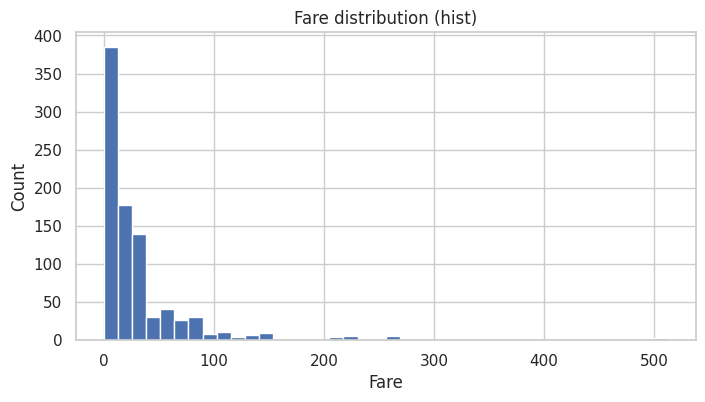

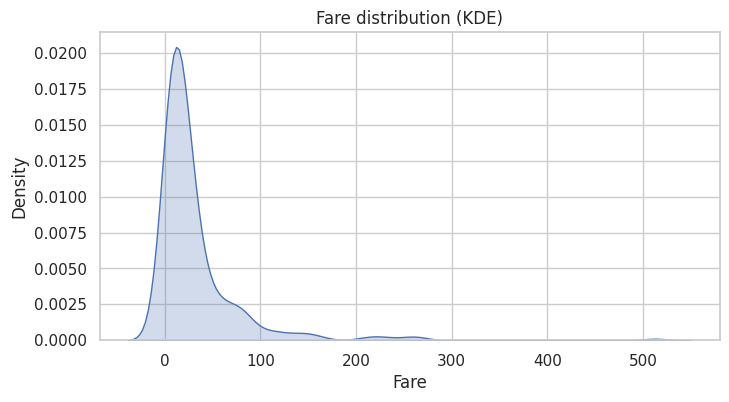

In [61]:
plt.hist(df["Fare"], bins=40)
plt.title("Fare distribution (hist)")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

sns.kdeplot(data=df, x="Fare", fill=True)
plt.title("Fare distribution (KDE)")
plt.show()

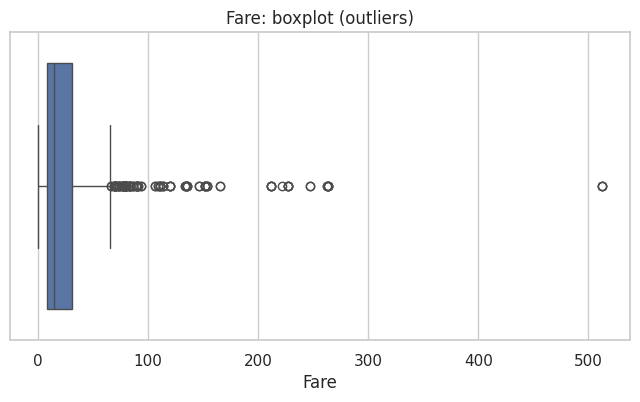

In [62]:
sns.boxplot(data=df, x="Fare")
plt.title("Fare: boxplot (outliers)")
plt.show()

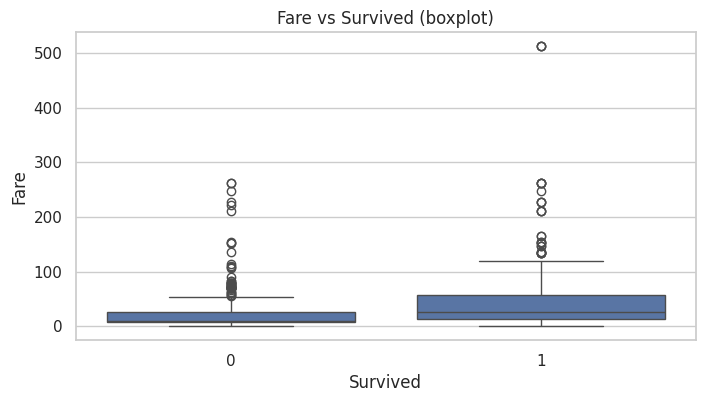

In [64]:
sns.boxplot(data=df, x=target_col, y="Fare")
plt.title("Fare vs Survived (boxplot)")
plt.show()

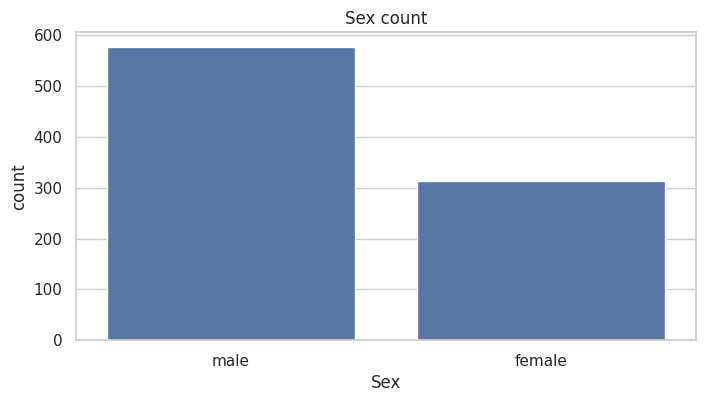

In [65]:
sns.countplot(data=df, x="Sex")
plt.title("Sex count")
plt.show()

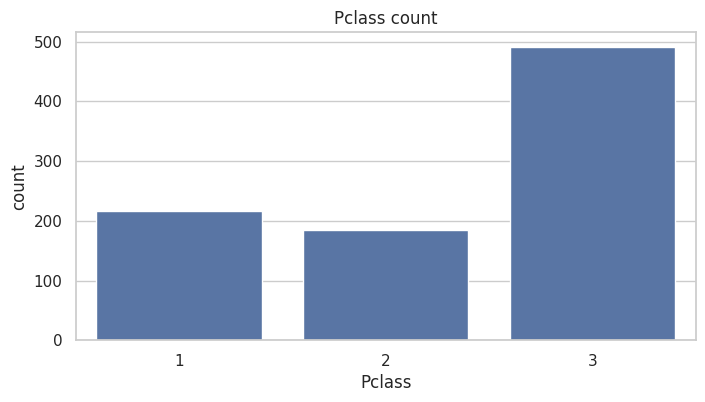

In [66]:
sns.countplot(data=df, x="Pclass")
plt.title("Pclass count")
plt.show()

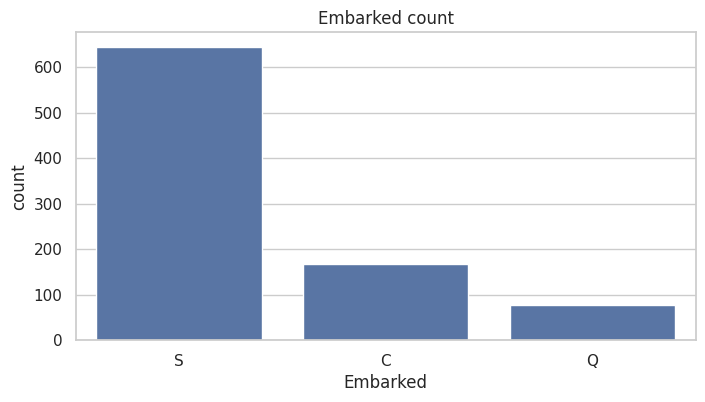

In [67]:
sns.countplot(data=df, x="Embarked")
plt.title("Embarked count")
plt.show()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

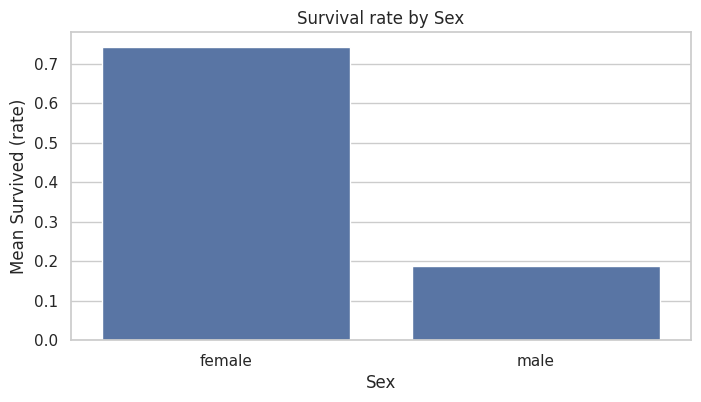

In [69]:
surv_by_sex = df.groupby("Sex")[target_col].mean().sort_values(ascending=False)
display(surv_by_sex)

sns.barplot(x=surv_by_sex.index, y=surv_by_sex.values)
plt.title("Survival rate by Sex")
plt.ylabel("Mean Survived (rate)")
plt.show()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

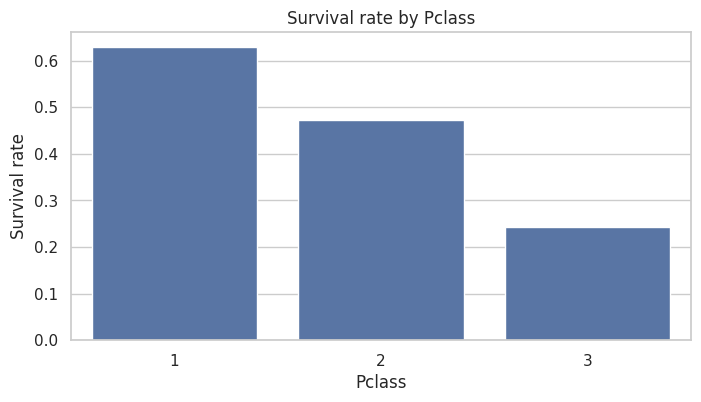

In [70]:
surv_by_pclass = df.groupby("Pclass")[target_col].mean()
display(surv_by_pclass)

sns.barplot(x=surv_by_pclass.index, y=surv_by_pclass.values)
plt.title("Survival rate by Pclass")
plt.ylabel("Survival rate")
plt.show()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

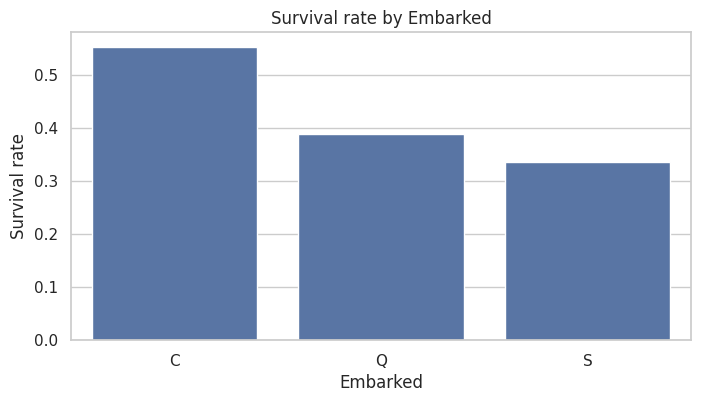

In [72]:
surv_by_embarked = df.groupby("Embarked")[target_col].mean().sort_values(ascending=False)
display(surv_by_embarked)

sns.barplot(x=surv_by_embarked.index, y=surv_by_embarked.values)
plt.title("Survival rate by Embarked")
plt.ylabel("Survival rate")
plt.show()


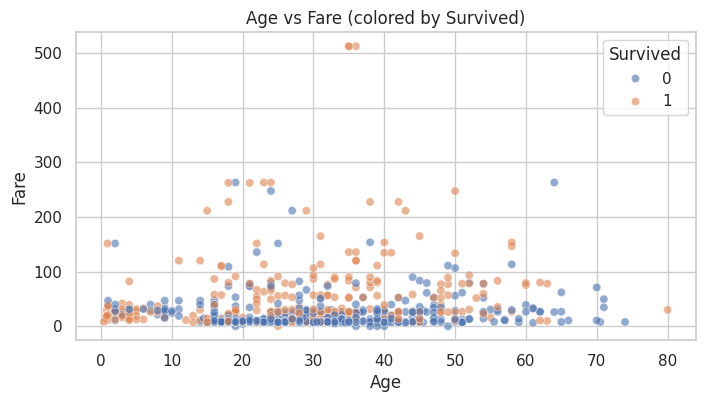

In [74]:
sns.scatterplot(data=df, x="Age", y="Fare", hue=target_col, alpha=0.6)
plt.title("Age vs Fare (colored by Survived)")
plt.show()

AgeBin
(0, 12]     0.579710
(12, 18]    0.428571
(18, 30]    0.355556
(30, 45]    0.425743
(45, 60]    0.407407
(60, 80]    0.227273
Name: Survived, dtype: float64

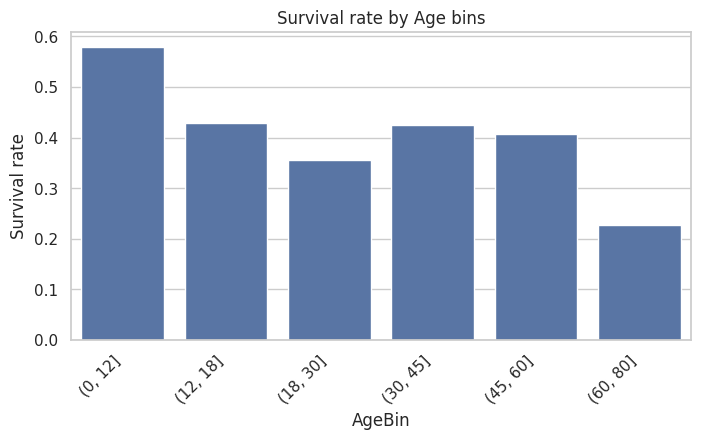

In [76]:
df["AgeBin"] = pd.cut(df["Age"], bins=[0, 12, 18, 30, 45, 60, 80])\

surv_by_agebin = df.groupby("AgeBin", observed=True)[target_col].mean()
display(surv_by_agebin)

sns.barplot(x=surv_by_agebin.index.astype(str), y=surv_by_agebin.values)
plt.xticks(rotation=45, ha="right")
plt.title("Survival rate by Age bins")
plt.ylabel("Survival rate")
plt.show()

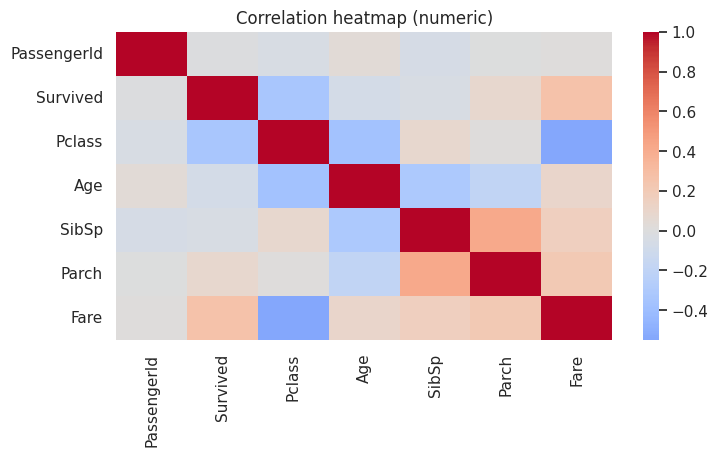

In [77]:
num_df = df.select_dtypes(include="number")
corr = num_df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap (numeric)")
plt.show()


In [80]:
corr_abs = corr.abs().unstack().sort_values(ascending=False)
corr_abs = corr_abs[corr_abs < 1.0]  # убрать (x,x)=1
display(corr_abs.head(10))

Fare      Pclass      0.549500
Pclass    Fare        0.549500
Parch     SibSp       0.414838
SibSp     Parch       0.414838
Age       Pclass      0.369226
Pclass    Age         0.369226
Survived  Pclass      0.338481
Pclass    Survived    0.338481
Age       SibSp       0.308247
SibSp     Age         0.308247
dtype: float64

In [82]:
fig = px.scatter(
    df,
    x="Age",
    y="Fare",
    color=target_col,
    hover_data=["Name", "Sex", "Pclass", "Embarked"],
    title="Age vs Fare (interactive)"
)
fig.show()

In [85]:
tmp = df.groupby("Sex", as_index=False)[target_col].mean()
fig = px.bar(tmp, x="Sex", y=target_col, title="Survival rate by Sex")
fig.show()